# Deep Learning — Week 1: NumPy · Matplotlib · Linear Regression

**Student Version**

---

## 이번 주 학습 목표
1. NumPy 배열의 shape를 이해하고, slicing·reshape·행렬 곱을 자유롭게 다룰 수 있다
2. Matplotlib으로 데이터와 학습 곡선을 시각화할 수 있다
3. 경사하강법으로 선형회귀를 직접 구현하고, 다변수로 확장할 수 있다

## 사전 학습 안내
> 영상을 먼저 보고 오세요.  
> **Part 1 전체를 직접 실행**해보는 것이 사전 학습 과제입니다.

## 참고 자료
> 📌 NumPy를 한 페이지로 정리한 치트시트:  
> - **[DataCamp NumPy Cheat Sheet (PDF)](https://assets.datacamp.com/blog_assets/Numpy_Python_Cheat_Sheet.pdf)** — 가장 깔끔한 1페이지 요약
> - **[quickref.me/numpy](https://quickref.me/numpy.html)** — 브라우저에서 빠르게 찾아볼 수 있는 레퍼런스
> - **[NumPy 공식 문서](https://numpy.org/doc/stable/user/absolute_beginners.html)** — 영어지만 예제가 풍부함

---
# Part 1. 강의 내용 (영상과 동일)

> 이 파트는 영상에서 설명한 코드입니다.  
> 실습 시간에 직접 실행하면서 결과를 확인하세요.

## 1. NumPy 기초

NumPy는 딥러닝 연산의 기반입니다.  
데이터, 가중치, 출력 — 모든 것이 **배열(array)** 로 표현됩니다.

파이썬 리스트와 비교했을 때 NumPy 배열의 장점:
- **훨씬 빠름**: 내부가 C로 구현되어 있어 수치 연산이 수십~수백 배 빠릅니다
- **벡터 연산**: for 루프 없이 배열 전체에 연산을 적용할 수 있습니다
- **편리한 선형대수**: 행렬 곱, 전치, 역행렬 등을 간단히 처리합니다

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)

NumPy version: 2.4.2


### 1-1. 배열 만들기와 shape

딥러닝 코드를 읽을 때 **shape를 항상 확인하는 습관**이 가장 중요합니다.  
shape가 맞지 않으면 연산이 실패하거나, 더 나쁘게는 의도치 않은 결과가 조용히 나옵니다.

```
shape (50,)   → 1차원 배열, 원소 50개  (벡터)
shape (50, 1) → 2차원 배열, 50행 1열   (열벡터)
shape (3, 4)  → 2차원 배열, 3행 4열    (행렬)
```


In [2]:
# 1D array (vector)
a = np.array([1, 2, 3, 4, 5])
print('1D array:', a)
print('  shape:', a.shape)   # (5,)
print('  dtype:', a.dtype)   # int64
print('  ndim :', a.ndim)    # 1 (차원 수)

print()

# 2D array (matrix)
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print('2D array:\n', A)
print('  shape:', A.shape)   # (2, 3) → 2행 3열
print('  size :', A.size)    # 6 (전체 원소 수)

print()

# 자주 쓰는 생성 함수
print('np.zeros((2,3)):\n', np.zeros((2, 3)))       # 영행렬
print('np.ones((2,3)):\n',  np.ones((2, 3)))        # 일행렬
print('np.eye(3):\n',       np.eye(3))              # 단위행렬
print('np.arange(0,10,2):', np.arange(0, 10, 2))   # [0,2,4,6,8]
print('np.linspace(0,1,5):', np.linspace(0, 1, 5)) # 균등 5개

np.random.seed(42)
print('np.random.randn(2,3):\n', np.random.randn(2, 3))  # 표준정규분포

1D array: [1 2 3 4 5]
  shape: (5,)
  dtype: int64
  ndim : 1

2D array:
 [[1 2 3]
 [4 5 6]]
  shape: (2, 3)
  size : 6

np.zeros((2,3)):
 [[0. 0. 0.]
 [0. 0. 0.]]
np.ones((2,3)):
 [[1. 1. 1.]
 [1. 1. 1.]]
np.eye(3):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
np.arange(0,10,2): [0 2 4 6 8]
np.linspace(0,1,5): [0.   0.25 0.5  0.75 1.  ]
np.random.randn(2,3):
 [[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]]


### 1-2. 인덱싱과 슬라이싱

딥러닝에서 **미니배치(mini-batch)** 를 꺼낼 때 항상 슬라이싱을 사용합니다.  
파이썬 리스트 슬라이싱과 문법이 같지만, 2D·3D 배열로 확장됩니다.

```
A[행, 열]
A[시작:끝, 시작:끝]   ← 끝 인덱스는 포함되지 않음
A[:, 0]              ← 모든 행의 0번 열
A[0, :]              ← 0번 행의 모든 열
```

In [3]:
A = np.array([[ 1,  2,  3,  4],
              [ 5,  6,  7,  8],
              [ 9, 10, 11, 12]])
print('A:\n', A)
print('shape:', A.shape)  # (3, 4)

print()
print('A[0]        :', A[0])          # 첫 번째 행 → [1, 2, 3, 4]
print('A[1, 2]     :', A[1, 2])       # 1행 2열 → 7
print('A[:, 0]     :', A[:, 0])       # 모든 행의 0열 → [1, 5, 9]
print('A[0:2, 1:3] :\n', A[0:2, 1:3]) # 0~1행, 1~2열
print('A[-1]       :', A[-1])         # 마지막 행
print('A[:, -1]    :', A[:, -1])      # 마지막 열
print('A[::2]      :\n', A[::2])      # 한 행 건너뛰며 (0번, 2번 행)

A:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
shape: (3, 4)

A[0]        : [1 2 3 4]
A[1, 2]     : 7
A[:, 0]     : [1 5 9]
A[0:2, 1:3] :
 [[2 3]
 [6 7]]
A[-1]       : [ 9 10 11 12]
A[:, -1]    : [ 4  8 12]
A[::2]      :
 [[ 1  2  3  4]
 [ 9 10 11 12]]


In [4]:
# Fancy indexing — 원하는 행/열을 리스트로 지정
A = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

print('A[[0, 2]]   :\n', A[[0, 2]])      # 0번, 2번 행만 선택
print('A[:, [0, 2]]:\n', A[:, [0, 2]])   # 0번, 2번 열만 선택

print()

# Boolean indexing — 조건에 맞는 원소만 선택
a = np.array([-3, -1, 0, 2, 4, -2, 5])
print('원래:', a)
print('양수만:', a[a > 0])               # [2, 4, 5]

# np.where — 조건에 따라 값 선택 (ReLU 구현과 원리가 같음)
relu_a = np.where(a > 0, a, 0)
print('ReLU:', relu_a)                   # [0, 0, 0, 2, 4, 0, 5]

A[[0, 2]]   :
 [[10 20 30]
 [70 80 90]]
A[:, [0, 2]]:
 [[10 30]
 [40 60]
 [70 90]]

원래: [-3 -1  0  2  4 -2  5]
양수만: [2 4 5]
ReLU: [0 0 0 2 4 0 5]


### 1-3. reshape와 axis

딥러닝 코드에서 shape 오류가 나는 이유의 대부분은 **reshape를 빠뜨렸거나 axis를 잘못 지정**했기 때문입니다.

**reshape** — 원소 수는 그대로, 배열의 모양만 바꿉니다
```
(6,) → reshape(2, 3) → (2, 3)   ← 원소 수 동일: 6 = 2×3
(6,) → reshape(6, 1) → (6, 1)   ← 열벡터: 딥러닝에서 자주 필요
(6,) → reshape(-1, 2)→ (3, 2)   ← -1은 "알아서 계산"
```

**axis** — 어느 방향으로 연산할 것인가
```
axis=0 → 행(row) 방향 ↓   (각 열에 대해 연산)
axis=1 → 열(col) 방향 →   (각 행에 대해 연산)
```

In [5]:
a = np.arange(12)   # [0, 1, 2, ..., 11]
print('원래:', a, '| shape:', a.shape)   # (12,)

print('reshape(3,4):\n',  a.reshape(3, 4))
print('reshape(12,1):\n', a.reshape(12, 1), '| shape:', a.reshape(12,1).shape)
print('reshape(-1,4):\n', a.reshape(-1, 4), '| shape:', a.reshape(-1,4).shape)

# flatten — 어떤 모양이든 1D로 만들기
B = np.array([[1,2,3],[4,5,6]])
print('flatten:', B.flatten())   # [1, 2, 3, 4, 5, 6]

# transpose — 행과 열 바꾸기
print('B.T:\n', B.T, '| shape:', B.T.shape)  # (2,3) → (3,2)

원래: [ 0  1  2  3  4  5  6  7  8  9 10 11] | shape: (12,)
reshape(3,4):
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
reshape(12,1):
 [[ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]] | shape: (12, 1)
reshape(-1,4):
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]] | shape: (3, 4)
flatten: [1 2 3 4 5 6]
B.T:
 [[1 4]
 [2 5]
 [3 6]] | shape: (3, 2)


In [6]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print('A:\n', A, '| shape:', A.shape)   # (2, 3)

print('np.sum(A)          :', np.sum(A))                       # 전체 합: 21
print('np.sum(A, axis=0)  :', np.sum(A, axis=0))               # 열방향: [5,7,9]
print('np.sum(A, axis=1)  :', np.sum(A, axis=1))               # 행방향: [6,15]
print('np.mean(A, axis=1) :', np.mean(A, axis=1))              # 행평균: [2.,5.]
print('np.max(A, axis=0)  :', np.max(A, axis=0))               # 열최댓값: [4,5,6]

print()
# keepdims=True — shape를 유지 (브로드캐스팅에 필요)
s = np.sum(A, axis=1, keepdims=True)
print('keepdims=True shape:', s.shape)   # (2,1) — (2,)가 아님!
print(s)

A:
 [[1 2 3]
 [4 5 6]] | shape: (2, 3)
np.sum(A)          : 21
np.sum(A, axis=0)  : [5 7 9]
np.sum(A, axis=1)  : [ 6 15]
np.mean(A, axis=1) : [2. 5.]
np.max(A, axis=0)  : [4 5 6]

keepdims=True shape: (2, 1)
[[ 6]
 [15]]


### 1-4. 행렬 곱 — 신경망 forward pass의 핵심

가장 많이 헷갈리는 부분입니다. **원소별 곱셈(`*`)과 행렬 곱(`@`)은 완전히 다릅니다.**

| 연산 | 기호 | 의미 | shape 예 |
|---|---|---|---|
| 원소별 곱 | `a * b` | 같은 위치끼리 곱 | `(3,) * (3,)` → `(3,)` |
| 행렬 곱  | `A @ B` | 내적 방식으로 곱 | `(2,3) @ (3,4)` → `(2,4)` |

신경망에서 $Z = XW + b$ 의 $XW$는 반드시 **행렬 곱**입니다.

행렬 곱의 shape 규칙:  `(m, k) @ (k, n)` → `(m, n)` — **앞 행렬의 열 수 = 뒤 행렬의 행 수**

In [7]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])

print('Element-wise  a * b :', a * b)        # [4, 10, 18]
print('Dot product   a @ b :', a @ b)        # 32.0
print('np.dot(a, b)       :', np.dot(a, b)) # 동일

print()

# 신경망 forward pass와 동일한 구조
# 샘플 5개, 입력 특성 3개 → 출력 2개
np.random.seed(0)
X = np.random.randn(5, 3)   # (5, 3) — 입력 데이터
W = np.random.randn(3, 2)   # (3, 2) — 가중치
b = np.zeros(2)             # (2,)   — bias

Z = X @ W + b               # (5, 3) @ (3, 2) → (5, 2)  + broadcast
print('X shape:', X.shape)
print('W shape:', W.shape)
print('Z = X@W + b, shape:', Z.shape)   # (5, 2)

Element-wise  a * b : [ 4. 10. 18.]
Dot product   a @ b : 32.0
np.dot(a, b)       : 32.0

X shape: (5, 3)
W shape: (3, 2)
Z = X@W + b, shape: (5, 2)


### 1-5. 브로드캐스팅

크기가 다른 배열끼리도 연산이 가능합니다.  
딥러닝에서 bias 덧셈 등에 자동으로 적용됩니다.

```
규칙: 뒤에서부터 차원을 맞추고, 크기가 1이면 늘어날 수 있다

(5, 3) + (3,)   → (3,)가 (5, 3)으로 확장 → 가능
(5, 3) + (5, 1) → (5,1)이 (5, 3)으로 확장 → 가능
(5, 3) + (5,)   → 차원 맞추기 불가 → 오류
```

In [8]:
# scalar + array
a = np.array([1, 2, 3])
print('a + 10:', a + 10)   # [11, 12, 13]

# 2D + 1D (bias 덧셈)
Z = np.array([[1, 2, 3],
              [4, 5, 6]])
bias = np.array([10, 20, 30])   # (3,) → 각 행에 더해짐
print('Z + bias:\n', Z + bias)

# 2D + column vector
col = np.array([[100],
                [200]])          # (2,1) → 각 열에 더해짐
print('Z + col:\n', Z + col)

a + 10: [11 12 13]
Z + bias:
 [[11 22 33]
 [14 25 36]]
Z + col:
 [[101 102 103]
 [204 205 206]]


---
## 2. Matplotlib 기초

딥러닝에서 시각화는 디버깅의 핵심입니다.  
**loss가 줄고 있는지**, **데이터 분포가 어떤지**를 항상 눈으로 확인하세요.  

> 주의: plot의 label, legend 텍스트는 **영어**로 작성하세요.  
> 한글 폰트가 설치되지 않으면 □□□로 깨져서 보입니다.

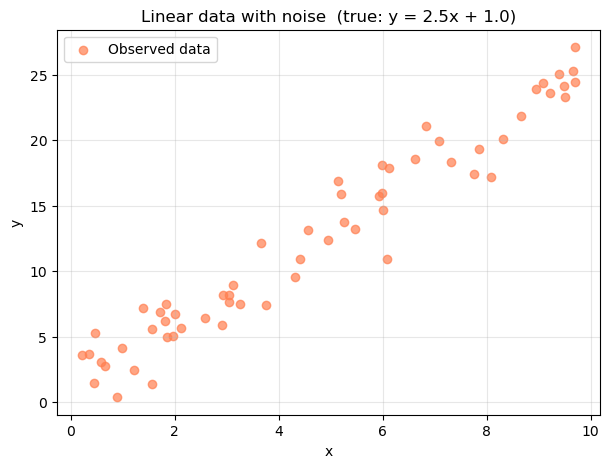

In [9]:
# Dataset we'll use for the rest of this notebook
np.random.seed(42)
N = 60
x_data = np.random.uniform(0, 10, N)
y_data = 2.5 * x_data + 1.0 + np.random.randn(N) * 2   # true: w=2.5, b=1.0

plt.figure(figsize=(7, 5))
plt.scatter(x_data, y_data, color='coral', alpha=0.7, label='Observed data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear data with noise  (true: y = 2.5x + 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

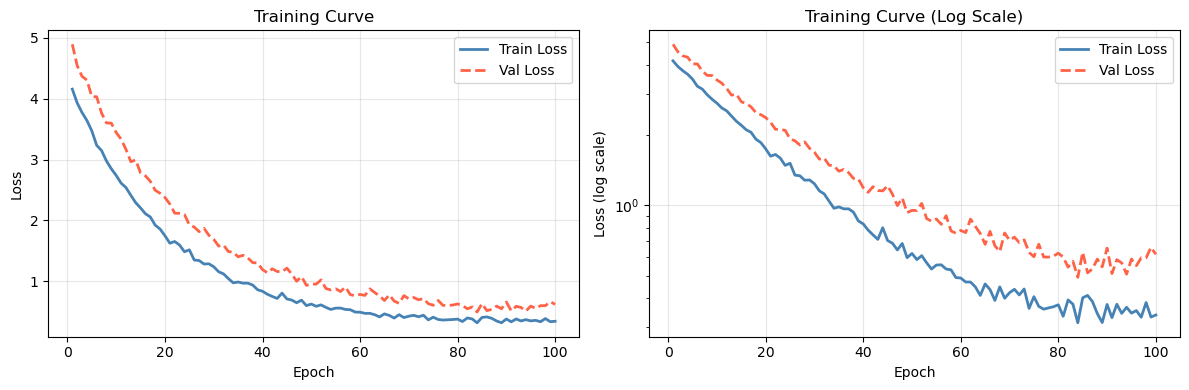

In [10]:
# Subplot — loss curve example (preview of what we'll plot after training)
epochs = np.arange(1, 101)
np.random.seed(0)
train_loss = 4.0 * np.exp(-0.05 * epochs) + 0.3 + np.random.randn(100) * 0.03
val_loss   = 4.5 * np.exp(-0.045 * epochs) + 0.5 + np.random.randn(100) * 0.05

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs, val_loss,   label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(epochs, train_loss, label='Train Loss', color='steelblue', linewidth=2)
axes[1].semilogy(epochs, val_loss,   label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Training Curve (Log Scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. 선형회귀 (Linear Regression)

### 선형회귀란?

**"입력 $x$와 출력 $y$ 사이의 관계를 직선으로 표현하는 것"** 입니다.

예를 들어,
- 공부 시간(x) → 시험 점수(y)
- 집 크기(x) → 집 가격(y)
- 광고비(x) → 매출(y)

이런 관계를 $\hat{y} = wx + b$ 직선 하나로 설명하려는 것이 선형회귀입니다.

### 우리가 찾아야 할 것

데이터 $\{(x_1, y_1), (x_2, y_2), \ldots, (x_N, y_N)\}$가 주어졌을 때,  
**예측값 $\hat{y}_i = wx_i + b$ 가 실제값 $y_i$ 에 최대한 가깝도록** $w$와 $b$를 찾는 것입니다.

### 비용함수 (Cost Function) — MSE

"얼마나 틀렸는가"를 숫자 하나로 나타내는 함수입니다.

$$L(w, b) = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

예측이 실제값에 가까울수록 $L$이 작아집니다. 우리의 목표는 $L$을 최소화하는 것입니다.

### 경사하강법 (Gradient Descent) — 어떻게 찾는가

"산에서 눈을 감고 내려갈 때, 발밑이 가장 가파른 방향으로 한 걸음씩 내려간다"는 아이디어입니다.

$$w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}, \qquad b \leftarrow b - \alpha \cdot \frac{\partial L}{\partial b}$$

$\alpha$는 **학습률(learning rate)** — 한 걸음의 크기입니다.

MSE를 $w$, $b$로 편미분하면:

$$\frac{\partial L}{\partial w} = \frac{2}{N}\sum_i(\hat{y}_i - y_i)\cdot x_i, \qquad \frac{\partial L}{\partial b} = \frac{2}{N}\sum_i(\hat{y}_i - y_i)$$

### 딥러닝과의 연결

지금 구현하는 이 루프는, 나중에 배울 신경망에서도 **구조가 그대로** 반복됩니다.

| 선형회귀 (이번 주) | 신경망 (이후) |
|---|---|
| `y_pred = w * x + b` | Forward pass |
| `loss = MSE(y_pred, y)` | Loss 계산 |
| `dw, db` 수식으로 계산 | Backpropagation (자동 미분) |
| `w -= lr * dw` | `optimizer.step()` |

**[참고: MSE를 $w$, $b$로 편미분하는 과정]**
$$
L(w, b) = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2
$$

$\hat{y}_i = wx_i + b$ 를 대입하면:

$$
L(w, b) = \frac{1}{N}\sum_{i=1}^{N}(wx_i + b - y_i)^2
$$

이 형태에서 chain rule을 적용하면 미분이 바로 보입니다:

$$
\frac{\partial L}{\partial w}
= \frac{1}{N}\sum_{i=1}^{N} 2(wx_i + b - y_i) \cdot x_i
= \frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)\cdot x_i
$$

$$
\frac{\partial L}{\partial b}
= \frac{1}{N}\sum_{i=1}^{N} 2(wx_i + b - y_i) \cdot 1
= \frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)
$$

In [11]:
# ── 데이터 ───────────────────────────────────────────────
np.random.seed(42)
N = 60
x = np.random.uniform(0, 10, N)
y = 2.5 * x + 1.0 + np.random.randn(N) * 2   # true: w=2.5, b=1.0

# ── 파라미터 초기화 ───────────────────────────────────────
w, b = 0.0, 0.0
lr   = 0.01
epochs = 100
loss_history = []

# ── 학습 루프 ─────────────────────────────────────────────
for epoch in range(epochs):

    # 1) Forward pass — 예측값 계산
    y_pred = w * x + b

    # 2) Loss — MSE
    loss = np.mean((y_pred - y) ** 2)
    loss_history.append(loss)

    # 3) Gradient — 편미분
    dw = 2 * np.mean((y_pred - y) * x)
    db = 2 * np.mean(y_pred - y)

    # 4) Update — 경사하강
    w = w - lr * dw
    b = b - lr * db

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss:.4f} | w: {w:.4f} | b: {b:.4f}')

print(f'\nLearned : w = {w:.4f}, b = {b:.4f}')
print(f'True    : w = 2.5000, b = 1.0000')

Epoch  20 | Loss: 3.2466 | w: 2.5326 | b: 0.4737
Epoch  40 | Loss: 3.2160 | w: 2.5209 | b: 0.5507
Epoch  60 | Loss: 3.1917 | w: 2.5105 | b: 0.6193
Epoch  80 | Loss: 3.1724 | w: 2.5012 | b: 0.6804
Epoch 100 | Loss: 3.1571 | w: 2.4929 | b: 0.7348

Learned : w = 2.4929, b = 0.7348
True    : w = 2.5000, b = 1.0000


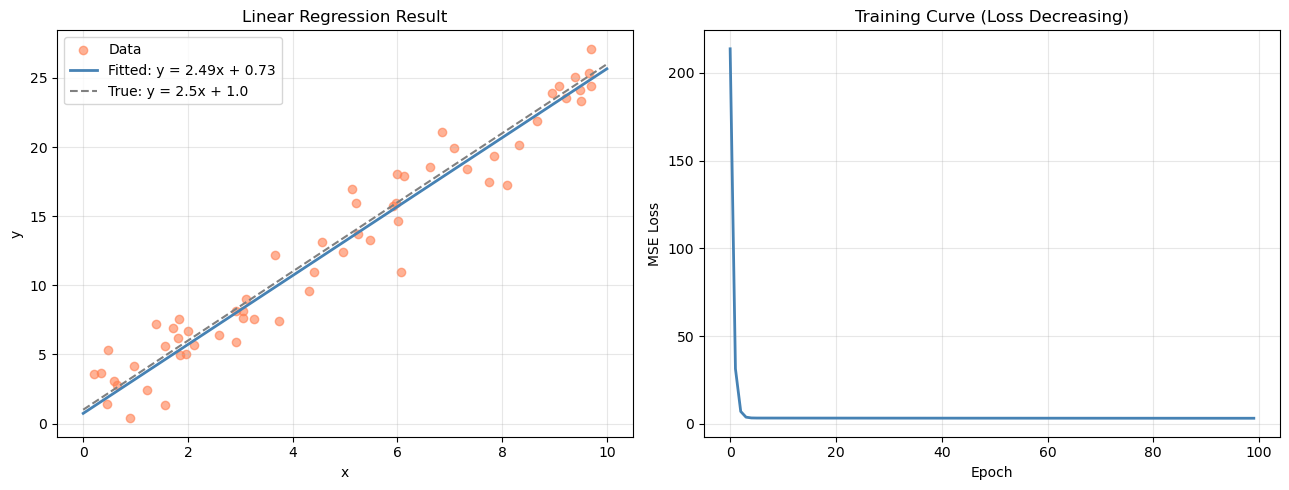

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: data + fitted line
x_line = np.linspace(0, 10, 100)
axes[0].scatter(x, y, color='coral', alpha=0.6, label='Data')
axes[0].plot(x_line, w * x_line + b, color='steelblue', linewidth=2,
             label=f'Fitted: y = {w:.2f}x + {b:.2f}')
axes[0].plot(x_line, 2.5 * x_line + 1.0, color='gray', linewidth=1.5,
             linestyle='--', label='True: y = 2.5x + 1.0')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Linear Regression Result')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: loss curve
axes[1].plot(loss_history, color='steelblue', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Training Curve (Loss Decreasing)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3-1. 학습률(Learning Rate)의 영향

학습률은 딥러닝에서 가장 먼저 조정해야 하는 하이퍼파라미터입니다.

| 학습률 | 결과 | 비유 |
|---|---|---|
| 너무 작음 | 수렴이 매우 느림 | 너무 조심스럽게 한 발씩 |
| 적당함 | 빠르고 안정적으로 수렴 | 적당한 보폭으로 하산 |
| 너무 큼 | loss가 발산 (튀어 오름) | 너무 큰 보폭으로 반대 사면으로 넘어감 |

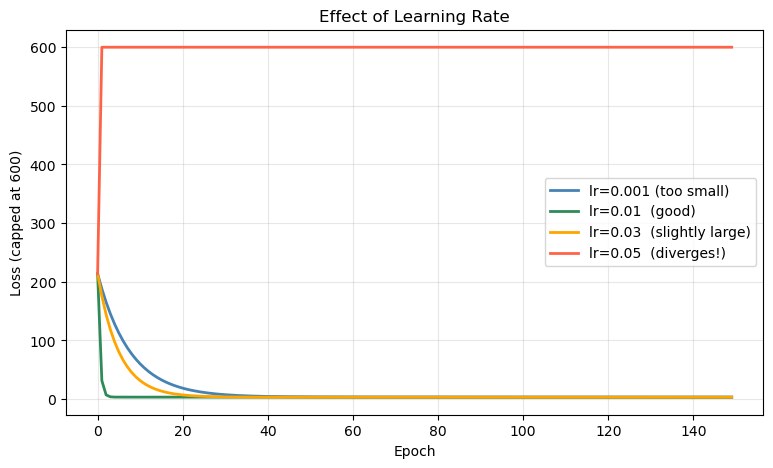

In [13]:
def train(x, y, lr, epochs=150):
    """Train linear regression, return loss history."""
    w, b = 0.0, 0.0
    losses = []
    for _ in range(epochs):
        y_pred = w * x + b
        loss = np.mean((y_pred - y) ** 2)
        losses.append(min(loss, 600))   # cap for visualization
        dw = 2 * np.mean((y_pred - y) * x)
        db = 2 * np.mean(y_pred - y)
        w -= lr * dw
        b -= lr * db
    return losses

configs = [(0.001, 'steelblue', 'lr=0.001 (too small)'),
           (0.01,  'seagreen',  'lr=0.01  (good)'),
           (0.03,  'orange',    'lr=0.03  (slightly large)'),
           (0.05,  'tomato',    'lr=0.05  (diverges!)')]

plt.figure(figsize=(9, 5))
for lr_val, color, label in configs:
    plt.plot(train(x, y, lr=lr_val), label=label, color=color, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Loss (capped at 600)')
plt.title('Effect of Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 4. 다변수 선형회귀 (Multivariate Linear Regression)

### 다변수 선형회귀란?

**입력 특성(feature)이 여러 개**일 때의 선형회귀입니다.

예를 들어 집 가격을 예측할 때:
- 집 크기만 보는 것 → 단변수 선형회귀
- 집 크기 + 방 개수 + 위치 + 층수를 모두 보는 것 → **다변수 선형회귀**

이런 경우, 모델은 아래와 같이 표현됩니다:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_p x_p + b$$

### 행렬로 표현하면 — 신경망과 완전히 같은 구조

N개의 샘플, p개의 특성이 있을 때, 이를 행렬로 묶으면:

$$
X = \begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1p} \\
x_{21} & x_{22} & \cdots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{N1} & x_{N2} & \cdots & x_{Np}
\end{pmatrix}
\quad (N \times p),
\qquad
\mathbf{w} = \begin{pmatrix} w_1 \\ w_2 \\ \vdots \\ w_p \end{pmatrix}
\quad (p \times 1)
$$

$$\hat{\mathbf{y}} = X\mathbf{w} + b \quad (N \times 1)$$

이 $X\mathbf{w}$가 바로 **행렬 곱**입니다. 신경망의 forward pass도 이 형태입니다.

### Gradient (행렬 버전)

$$\frac{\partial L}{\partial \mathbf{w}} = \frac{2}{N} X^T (\hat{\mathbf{y}} - \mathbf{y}), \qquad \frac{\partial L}{\partial b} = \frac{2}{N} \sum_i (\hat{y}_i - y_i)$$

단변수와 구조가 같습니다. 단지 스칼라 곱이 행렬 곱으로 바뀌었을 뿐입니다.

In [14]:
# ── Problem: predict house price from size + number of rooms ──
# True relationship: price = 3.0 * size + 10.0 * rooms + 50.0 + noise

np.random.seed(42)
N = 80
size  = np.random.uniform(50, 150, N)          # house size (m²)
rooms = np.random.randint(1, 6, N).astype(float)  # number of rooms
price = 3.0 * size + 10.0 * rooms + 50.0 + np.random.randn(N) * 20

# Build X matrix: (N, 2) and y vector: (N, 1)
X    = np.column_stack([size, rooms])   # (80, 2)
y_mv = price.reshape(-1, 1)             # (80, 1)

print('X shape:', X.shape)    # (80, 2)
print('y shape:', y_mv.shape) # (80, 1)
print('\nFirst 3 samples:')
print('  size  rooms  price')
for i in range(3):
    print(f'  {size[i]:.1f}  {rooms[i]:.0f}  {price[i]:.1f}')

X shape: (80, 2)
y shape: (80, 1)

First 3 samples:
  size  rooms  price
  87.5  1  313.5
  145.1  4  523.5
  123.2  2  464.3


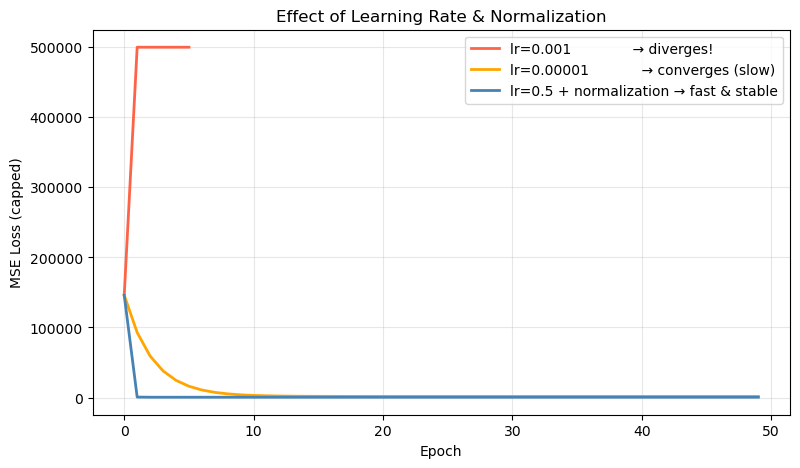

─────────────────────────────────────────────
Final parameters (converged runs only)
─────────────────────────────────────────────

[lr=0.00001 (no normalization)]
  w: size=3.7493, rooms=0.1549
  b: 0.0443

[lr=0.5    (with normalization)]
  w (original scale): size=2.8864, rooms=10.4391
  b (original scale): 62.3061

True values : w=[3.0, 10.0], b=50.0
─────────────────────────────────────────────


In [15]:
# ── 학습률에 따라 어떻게 달라지는지 먼저 비교해봅니다 ────
def train_mv(X, y, lr, epochs=50):
    """Train multivariate linear regression, return loss history."""
    w = np.zeros((X.shape[1], 1))
    b = 0.0
    losses = []
    for _ in range(epochs):
        y_pred = X @ w + b
        loss = np.mean((y_pred - y) ** 2)
        if np.isnan(loss) or loss > 1e20:   # stop if diverged
            losses.extend([float('nan')] * (epochs - len(losses)))
            break
        losses.append(loss)
        diff = y_pred - y
        w -= lr * (2 / len(y)) * X.T @ diff
        b -= lr * 2 * np.mean(diff)
    return losses, w, b

# Normalized features
size_n  = (size  - size.mean())  / size.std()
rooms_n = (rooms - rooms.mean()) / rooms.std()
X_norm  = np.column_stack([size_n, rooms_n])

configs = [(0.001,   'tomato',    'lr=0.001              → diverges!'),
           (0.00001, 'orange',    'lr=0.00001            → converges (slow)'),
           (0.5,     'steelblue', 'lr=0.5 + normalization → fast & stable')]

plt.figure(figsize=(9, 5))
import math
for i, (lr_val, color, label) in enumerate(configs):
    X_use = X_norm if i == 2 else X
    losses, _, _ = train_mv(X_use, y_mv, lr=lr_val)
    capped = [min(l, 5e5) if not math.isnan(l) else float('nan') for l in losses]
    plt.plot(capped, label=label, color=color, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss (capped)')
plt.title('Effect of Learning Rate & Normalization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ── 수렴한 경우 최종 파라미터 출력 ──────────────────────
print('─' * 45)
print('Final parameters (converged runs only)')
print('─' * 45)

converged_configs = [
    (0.00001, 'lr=0.00001 (no normalization)', X,      False),
    (0.5,     'lr=0.5    (with normalization)', X_norm, True),
]

for lr_val, label, X_use, normalized in converged_configs:
    _, w_f, b_f = train_mv(X_use, y_mv, lr=lr_val)
    print(f'\n[{label}]')
    if normalized:
        # Convert w back to original scale
        w_size  = w_f[0, 0] / size.std()
        w_rooms = w_f[1, 0] / rooms.std()
        b_orig  = b_f - w_f[0,0]*size.mean()/size.std() - w_f[1,0]*rooms.mean()/rooms.std()
        print(f'  w (original scale): size={w_size:.4f}, rooms={w_rooms:.4f}')
        print(f'  b (original scale): {b_orig:.4f}')
    else:
        print(f'  w: size={w_f[0,0]:.4f}, rooms={w_f[1,0]:.4f}')
        print(f'  b: {b_f:.4f}')

print(f'\nTrue values : w=[3.0, 10.0], b=50.0')
print('─' * 45)


---
---

# Part 2. 실습 문제

> **[A] 한 줄 채우기** — 8문제  
> **[B] 여러 줄 채우기** — 2문제 (힌트 제공)
>
> - `______` 로 표시된 부분만 채우세요
> - 막히면 위 Part 1의 같은 개념 코드를 참고하세요
> - [B] 문제 중 못 한 것은 숙제입니다

---
## [A] 한 줄 채우기

In [16]:
# ─────────────────────────────────────────────
# A-1. numpy와 matplotlib 불러오기
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# ─────────────────────────────────────────────
# A-2. shape 확인
# A의 shape를 출력하세요
# Expected: (3, 4)
# ─────────────────────────────────────────────
A = np.ones((3, 4))
print(A.shape)

(3, 4)


In [18]:
# ─────────────────────────────────────────────
# A-3. 슬라이싱
# A에서 1번 행의 모든 원소를 꺼내세요
# Expected: [5 6 7 8]
# ─────────────────────────────────────────────
A = np.array([[ 1,  2,  3,  4],
              [ 5,  6,  7,  8],
              [ 9, 10, 11, 12]])
print(A[1, :]) # print(A[1]도 작동함

[5 6 7 8]


In [19]:
# ─────────────────────────────────────────────
# A-4. reshape
# a를 (3, 4) 형태로 바꾸세요
# Expected shape: (3, 4)
# ─────────────────────────────────────────────
a = np.arange(12)
b = np.reshape(a, (3, 4))
print('shape:', b.shape)

shape: (3, 4)


In [20]:
# ─────────────────────────────────────────────
# A-5. 행렬 곱
# X (4×3) 와 W (3×2) 의 행렬 곱을 계산하세요
# Expected shape: (4, 2)
# ─────────────────────────────────────────────
np.random.seed(0)
X = np.random.randn(4, 3)
W = np.random.randn(3, 2)

Z = X @ W  # <- W@X로 하면 안됨(규격 서로 안 맞음)
print('Z shape:', Z.shape)

Z shape: (4, 2)


In [21]:
# ─────────────────────────────────────────────
# A-6. axis 연산
# A의 각 행(row)의 평균을 구하세요
# Expected: [2. 5.]
# ─────────────────────────────────────────────
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print(np.mean(A, axis=1)) #axis가 0일시 열(column, 세로)방향, 1일시 행(row, 가로)방향

[2. 5.]


In [22]:
# ─────────────────────────────────────────────
# A-7. MSE loss 계산
# y_pred와 y_true 사이의 MSE를 계산하세요
# Expected: 0.25
# ─────────────────────────────────────────────
y_true = np.array([1.0, 2.0, 3.0, 4.0])
y_pred = np.array([1.5, 2.5, 2.5, 3.5])

loss = np.mean((y_true - y_pred)**2)
print('MSE:', loss)

MSE: 0.25


In [23]:
# ─────────────────────────────────────────────
# A-8. 파라미터 업데이트
# 경사하강법으로 w, b를 업데이트하세요
# Expected: w=0.9200, b=0.5300
# ─────────────────────────────────────────────
w, b = 1.0, 0.5
lr   = 0.1
dw, db = 0.8, -0.3

w = w - lr * dw #lr * dw는 w의 변화량(gradient)입니다. w에서 이 변화량을 빼면 w가 업데이트됩니다.
b = b - lr * db # lr은 learning rate, dw db는 각 w,b에 대한 편미분입니다. b에서 lr * db를 빼면 b가 업데이트됩니다.
print(f'w: {w:.4f}, b: {b:.4f}')

w: 0.9200, b: 0.5300


---
## [B] 여러 줄 채우기

Learned: w=1.7320, b=1.8808
True   : w=1.5000, b=3.0000


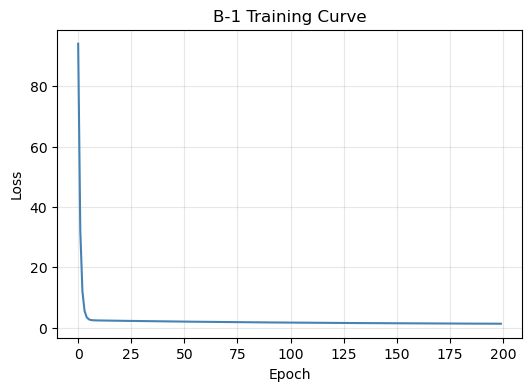

In [24]:
# ─────────────────────────────────────────────
# B-1. 단변수 선형회귀 학습 루프 완성
#
# Hint:
#   순서: ① y_pred → ② loss → ③ dw, db → ④ w, b 업데이트
#   dw = 2 * np.mean((y_pred - y) * x)
#   db = 2 * np.mean(y_pred - y)
# ─────────────────────────────────────────────
np.random.seed(7)
N = 50
x = np.random.uniform(0, 8, N)
y = 1.5 * x + 3.0 + np.random.randn(N)   # true: w=1.5, b=3.0

w, b = 0.0, 0.0
lr = 0.01
loss_history = []

for epoch in range(200):

    # ① Forward
    y_pred = w * x + b

    # ② Loss
    loss = np.mean((y-y_pred)**2)
    loss_history.append(loss)

    # ③ Gradient
    dw = 2 * np.mean((y_pred - y) * x)
    db = 2 * np.mean(y_pred - y)

    # ④ Update
    w = w - lr * dw
    b = b - lr * db

print(f'Learned: w={w:.4f}, b={b:.4f}')
print(f'True   : w=1.5000, b=3.0000')

plt.figure(figsize=(6,4))
plt.plot(loss_history, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('B-1 Training Curve')
plt.grid(True, alpha=0.3)
plt.show()

X shape: (60, 2)
y shape: (60, 1)
Final loss: 21.32


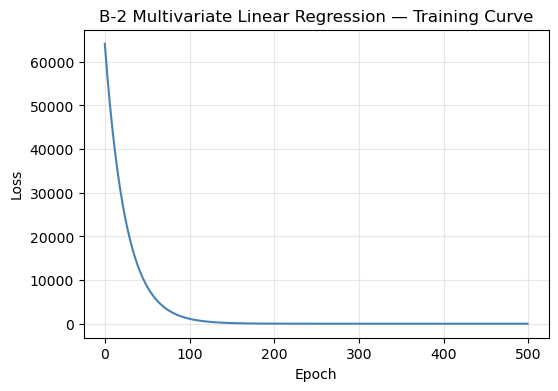

In [25]:
# ─────────────────────────────────────────────
# B-2. 다변수 선형회귀 (특성 2개)
#
# Problem: 온도(temp)와 습도(humidity)로 아이스크림 판매량(sales) 예측
# True: sales = 5.0 * temp + 2.0 * humidity + 10.0 + noise
#
# Hint:
#   특성을 정규화해야 학습이 안정적입니다:
#     x_norm = (x - x.mean()) / x.std()
#
#   X = np.column_stack([temp_norm, humidity_norm])  → shape (N, 2)
#   y = sales.reshape(-1, 1)                         → shape (N, 1)
#   w = np.zeros((2, 1))                             → shape (2, 1)
#
#   forward : y_pred = X @ w + b
#   gradient: dw = (2/N) * X.T @ (y_pred - y)
#             db = 2 * np.mean(y_pred - y)
# ─────────────────────────────────────────────
np.random.seed(42)
N = 60
temp     = np.random.uniform(15, 35, N)
humidity = np.random.uniform(40, 80, N)
sales    = 5.0 * temp + 2.0 * humidity + 10.0 + np.random.randn(N) * 5

# 특성 정규화 (평균 0, 표준편차 1)
temp_norm     = (temp - temp.mean()) / temp.std()
humidity_norm = (humidity - humidity.mean()) / humidity.std()

# 행렬로 묶기
X    = np.column_stack([temp_norm, humidity_norm])  # hint: np.column_stack([temp_norm, humidity_norm])
y_mv = sales.reshape(-1, 1)   # hint: sales.reshape(-1, 1)

print('X shape:', X.shape)    # (60, 2)
print('y shape:', y_mv.shape) # (60, 1)

# 파라미터 초기화
w_mv = np.zeros((2, 1))
b_mv = 0.0
lr_mv = 0.01    # 정규화 후에는 큰 학습률 사용 가능
loss_mv_hist = []

for epoch in range(500):

    # Forward
    y_pred_mv = X @ w_mv + b_mv

    # Loss
    loss_mv = np.mean((y_pred_mv - y_mv)**2)
    loss_mv_hist.append(loss_mv)

    # Gradient
    diff  = y_pred_mv - y_mv
    dw_mv = (2/N) * X.T @ diff
    db_mv = 2 * np.mean(diff)

    # Update
    w_mv = w_mv - lr_mv * dw_mv
    b_mv = b_mv - lr_mv * db_mv

print(f'Final loss: {loss_mv_hist[-1]:.2f}')

plt.figure(figsize=(6,4))
plt.plot(loss_mv_hist, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('B-2 Multivariate Linear Regression — Training Curve')
plt.grid(True, alpha=0.3)
plt.show()

---
## Checklist

**[A] 한 줄 채우기**
- [ ] A-1. import
- [ ] A-2. shape 출력
- [ ] A-3. 슬라이싱
- [ ] A-4. reshape
- [ ] A-5. 행렬 곱
- [ ] A-6. axis 연산
- [ ] A-7. MSE loss
- [ ] A-8. 파라미터 업데이트

**[B] 여러 줄 채우기**
- [ ] B-1. 단변수 선형회귀 루프 완성
- [ ] B-2. 다변수 선형회귀 완성 ← 못 한 경우 숙제

---
## 생각해볼 질문

1. B-2에서 `lr_mv = 0.001`로 바꾸면 어떻게 되나요? 왜 그럴까요?
2. B-1과 B-2의 학습 루프에서 **달라진 부분은 딱 두 곳**입니다. 어디인가요?
3. 특성이 10개로 늘어나도 코드에서 바꿔야 할 부분은 어디인가요?